In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Carrega datasets
energia_A = pd.read_csv('energia_202109-202112.csv', encoding='latin1')
energia_B = pd.read_csv('energia_202201-202212.csv', encoding='latin1')
meteo_A = pd.read_csv('meteo_202109-202112.csv', encoding='latin1')
meteo_B = pd.read_csv('meteo_202201-202212.csv', encoding='latin1')
energia = pd.concat([energia_A, energia_B], ignore_index=True)
meteo = pd.concat([meteo_A, meteo_B], ignore_index=True)

energia['timestamp'] = pd.to_datetime(energia['Data']) + pd.to_timedelta(energia['Hora'], unit='h')
meteo['dt_iso_clean'] = meteo['dt_iso'].str.replace(' \+0000 UTC', '', regex=True)
meteo['timestamp'] = pd.to_datetime(meteo['dt_iso_clean'], format='%Y-%m-%d %H:%M:%S')

features_meteo = ['timestamp', 'temp', 'feels_like', 'temp_min', 'temp_max',
                  'pressure', 'humidity', 'wind_speed', 'rain_1h',
                  'clouds_all', 'weather_description']
df = pd.merge(energia, meteo[features_meteo], on='timestamp', how='left')
for col in ['temp','feels_like','temp_min','temp_max','pressure',
            'humidity','wind_speed','clouds_all']:
    df[col] = df[col].fillna(df[col].mean())
df['rain_1h'] = df['rain_1h'].fillna(0)
df['weather_description'] = df['weather_description'].fillna('missing')
df['Injeção na rede (kWh)'] = df['Injeção na rede (kWh)'].fillna('None')

df_train = df.copy()
df_train['hour'] = df_train['timestamp'].dt.hour
df_train['dayofweek'] = df_train['timestamp'].dt.dayofweek
df_train['month'] = df_train['timestamp'].dt.month
df_train['is_weekend'] = (df_train['dayofweek'] >= 5).astype(int)
# Novas features cíclicas
df_train['hour_sin'] = np.sin(2 * np.pi * df_train['hour'] / 24)
df_train['hour_cos'] = np.cos(2 * np.pi * df_train['hour'] / 24)
df_train['month_sin'] = np.sin(2 * np.pi * df_train['month'] / 12)
df_train['month_cos'] = np.cos(2 * np.pi * df_train['month'] / 12)
df_train['temp_x_wind'] = df_train['temp'] * df_train['wind_speed']
df_train['autoc_x_temp'] = df_train['Autoconsumo (kWh)'] * df_train['temp']
df_train['prod_ratio'] = df_train['Autoconsumo (kWh)'] / (df_train['Normal (kWh)'] + 1)
numericas = ['temp','feels_like','temp_min','temp_max','pressure','humidity','wind_speed','clouds_all',
    'hour_sin','hour_cos','month_sin','month_cos','temp_x_wind','autoc_x_temp','prod_ratio'
]
imputer = KNNImputer(n_neighbors=5)
df_train[numericas] = imputer.fit_transform(df_train[numericas])
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
weather_ohe = ohe.fit_transform(df_train[['weather_description']])
weather_ohe_df = pd.DataFrame(weather_ohe, columns=ohe.get_feature_names_out(['weather_description']))
df_train = pd.concat([df_train, weather_ohe_df], axis=1)
scaler = StandardScaler()
df_train[numericas] = scaler.fit_transform(df_train[numericas])
le_target = LabelEncoder()
df_train['y'] = le_target.fit_transform(df_train['Injeção na rede (kWh)'])
target_names = [str(c) for c in le_target.classes_]

final_features = [
    'Normal (kWh)', 'Horário Económico (kWh)', 'Autoconsumo (kWh)',
    'hour', 'dayofweek', 'month', 'is_weekend'
] + numericas + list(weather_ohe_df.columns)
X = df_train[final_features].values
y = df_train['y'].values

# 2. Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Param grid expandido p/ accuracy máxima
param_grid = {
    'n_estimators': [250, 500, 1000],
    'max_depth': [20, 32, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=6, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

print('Melhores parâmetros:', grid_search.best_params_)
print('Melhor accuracy (valid.):', grid_search.best_score_)
y_val_pred = best_rf.predict(X_val)
print('Accuracy val:', accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=target_names))
print(confusion_matrix(y_val, y_val_pred))

# 4. TESTE
energia_test = pd.read_csv('energia_202301-202304.csv', encoding='latin1')
meteo_test = pd.read_csv('meteo_202301-202304.csv', encoding='latin1')
energia_test['timestamp'] = pd.to_datetime(energia_test['Data']) + pd.to_timedelta(energia_test['Hora'], unit='h')
meteo_test['dt_iso_clean'] = meteo_test['dt_iso'].str.replace(' \+0000 UTC', '', regex=True)
meteo_test['timestamp'] = pd.to_datetime(meteo_test['dt_iso_clean'], format='%Y-%m-%d %H:%M:%S')
df_test = pd.merge(energia_test, meteo_test[features_meteo], on='timestamp', how='left')

df_test['hour'] = df_test['timestamp'].dt.hour
df_test['dayofweek'] = df_test['timestamp'].dt.dayofweek
df_test['month'] = df_test['timestamp'].dt.month
df_test['is_weekend'] = (df_test['dayofweek'] >= 5).astype(int)
df_test['hour_sin'] = np.sin(2 * np.pi * df_test['hour'] / 24)
df_test['hour_cos'] = np.cos(2 * np.pi * df_test['hour'] / 24)
df_test['month_sin'] = np.sin(2 * np.pi * df_test['month'] / 12)
df_test['month_cos'] = np.cos(2 * np.pi * df_test['month'] / 12)
df_test['temp_x_wind'] = df_test['temp'] * df_test['wind_speed']
df_test['autoc_x_temp'] = df_test['Autoconsumo (kWh)'] * df_test['temp']
df_test['prod_ratio'] = df_test['Autoconsumo (kWh)'] / (df_test['Normal (kWh)'] + 1)

for col in numericas:
    df_test[col] = df_test[col].fillna(df_train[col].mean())
df_test['rain_1h'] = df_test['rain_1h'].fillna(0)
df_test['weather_description'] = df_test['weather_description'].fillna('missing')
df_test[numericas] = imputer.transform(df_test[numericas])
df_test.loc[~df_test['weather_description'].isin(ohe.categories_[0]), 'weather_description'] = 'missing'
weather_ohe_test = ohe.transform(df_test[['weather_description']])
weather_ohe_df_test = pd.DataFrame(weather_ohe_test, columns=ohe.get_feature_names_out(['weather_description']))
df_test = pd.concat([df_test, weather_ohe_df_test], axis=1)
df_test[numericas] = scaler.transform(df_test[numericas])
X_test = df_test[final_features].values

y_pred_test = best_rf.predict(X_test)
labels_pred = le_target.inverse_transform(y_pred_test)
dummy = pd.read_csv('dummy_submission.csv')
assert len(dummy) == len(labels_pred)
dummy['Result'] = labels_pred
dummy.to_csv('submission.csv', index=False)


<>:18: SyntaxWarning: invalid escape sequence '\+'
<>:97: SyntaxWarning: invalid escape sequence '\+'
<>:18: SyntaxWarning: invalid escape sequence '\+'
<>:97: SyntaxWarning: invalid escape sequence '\+'
/var/folders/cx/rl_qn7mn409324ckkc65lsnh0000gn/T/ipykernel_13215/1877930642.py:18: SyntaxWarning: invalid escape sequence '\+'
  meteo['dt_iso_clean'] = meteo['dt_iso'].str.replace(' \+0000 UTC', '', regex=True)
/var/folders/cx/rl_qn7mn409324ckkc65lsnh0000gn/T/ipykernel_13215/1877930642.py:97: SyntaxWarning: invalid escape sequence '\+'
  meteo_test['dt_iso_clean'] = meteo_test['dt_iso'].str.replace(' \+0000 UTC', '', regex=True)


Melhores parâmetros: {'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Melhor accuracy (valid.): 0.8858368127495951
Accuracy val: 0.882940108892922
              precision    recall  f1-score   support

        High       0.70      0.74      0.72       221
         Low       0.43      0.19      0.26        86
      Medium       0.62      0.70      0.66       220
        None       0.97      0.98      0.97      1556
   Very High       0.83      0.77      0.80       121

    accuracy                           0.88      2204
   macro avg       0.71      0.67      0.68      2204
weighted avg       0.88      0.88      0.88      2204

[[ 164    0   40    0   17]
 [   0   16   32   38    0]
 [  39   10  154   15    2]
 [   2   11   24 1519    0]
 [  28    0    0    0   93]]


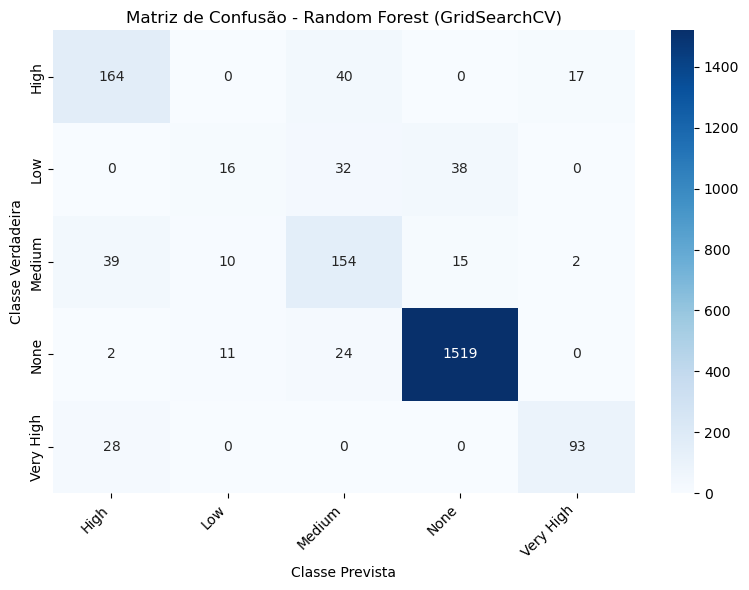

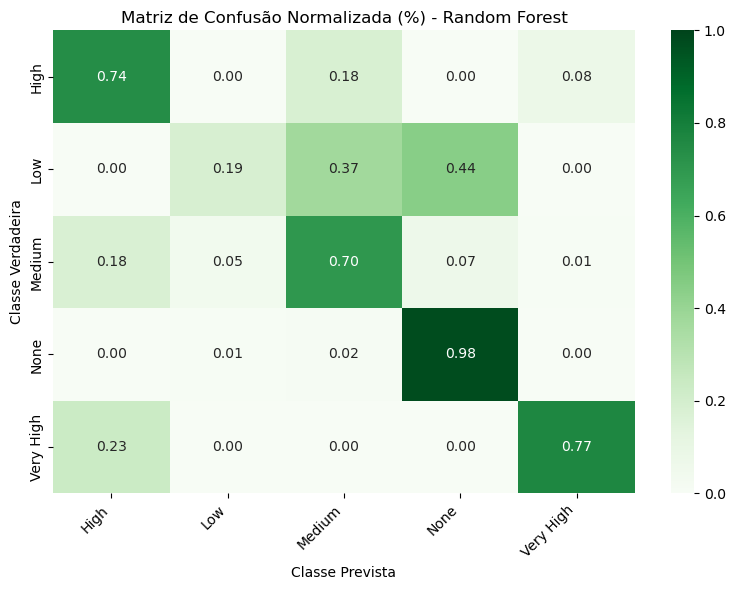

Imagens guardadas:
  → matriz_confusao_rf_grid.png
  → matriz_confusao_norm_rf_grid.png


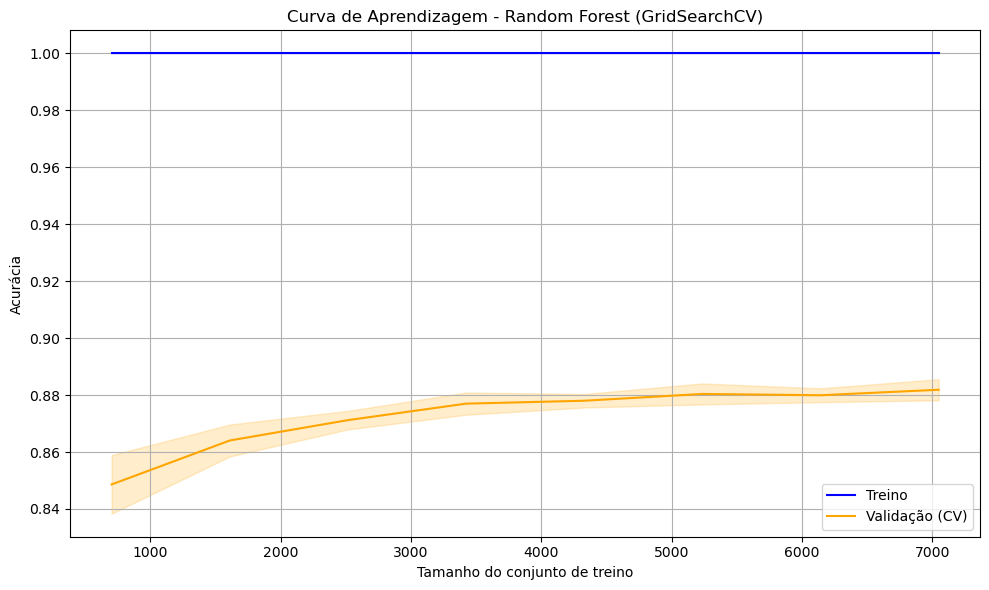

Imagem guardada:
  → curva_overfitting_rf_grid.png


In [2]:
# ==============================================================
# 5. AVALIAÇÃO VISUAL: MATRIZ DE CONFUSÃO + CURVA DE APRENDIZAGEM
# ==============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import learning_curve

# --- MATRIZ DE CONFUSÃO ---
cm = confusion_matrix(y_val, y_val_pred)
cm_norm = confusion_matrix(y_val, y_val_pred, normalize='true')

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Verdadeira")
plt.title("Matriz de Confusão - Random Forest (GridSearchCV)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("matriz_confusao_rf_grid.png", dpi=300)
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names, vmin=0, vmax=1)
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Verdadeira")
plt.title("Matriz de Confusão Normalizada (%) - Random Forest")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("matriz_confusao_norm_rf_grid.png", dpi=300)
plt.show()

print("Imagens guardadas:")
print("  → matriz_confusao_rf_grid.png")
print("  → matriz_confusao_norm_rf_grid.png")

# --- CURVA DE APRENDIZAGEM (overfitting) ---
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train, y_train,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, label="Treino", color="blue")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, color="blue", alpha=0.2)
plt.plot(train_sizes, val_mean, label="Validação (CV)", color="orange")
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, color="orange", alpha=0.2)
plt.title("Curva de Aprendizagem - Random Forest (GridSearchCV)")
plt.xlabel("Tamanho do conjunto de treino")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("curva_overfitting_rf_grid.png", dpi=300)
plt.show()

print("Imagem guardada:")
print("  → curva_overfitting_rf_grid.png")
